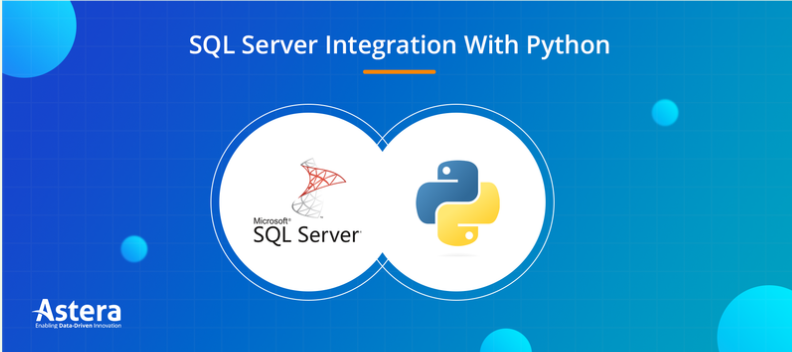

# How to link between SQL & Python ?

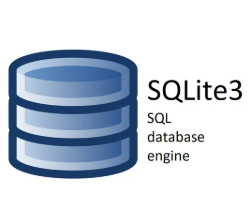

In [ ]:
import sqlite3
import pandas as pd

##How To Create Database ?

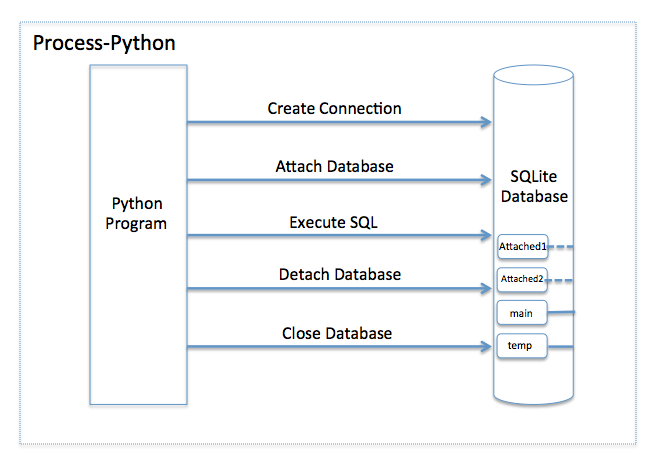

In [ ]:
db=sqlite3.connect('database_file.db')
db.close()

##How To Create Tables in Database ?

You cannot directly write and execute raw Python code inside a pure .sql file using a standard database cursor. A SQL cursor (cursor()) only sends SQL text commands to a database

1. cursor() -- write python code inside sql file


2. execute - function inside cursor()

In [ ]:
import sqlite3

db = sqlite3.connect('file1.db')

cursor = db.cursor()

cursor.execute("""
CREATE TABLE student (
    StudentID INTEGER PRIMARY KEY,
    FirstName VARCHAR(50) NOT NULL,
    LastName VARCHAR(50) NOT NULL,
    Gender VARCHAR(10),
    BirthDate DATE,
    Email VARCHAR(100)
)
""")

db.commit() # nafz el sql code
db.close()

#Create Table named Department , Student , course , Enrollment Table

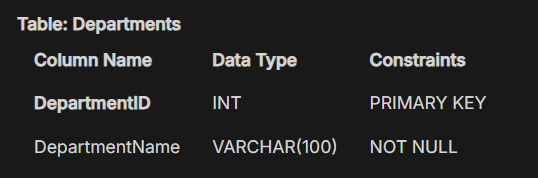

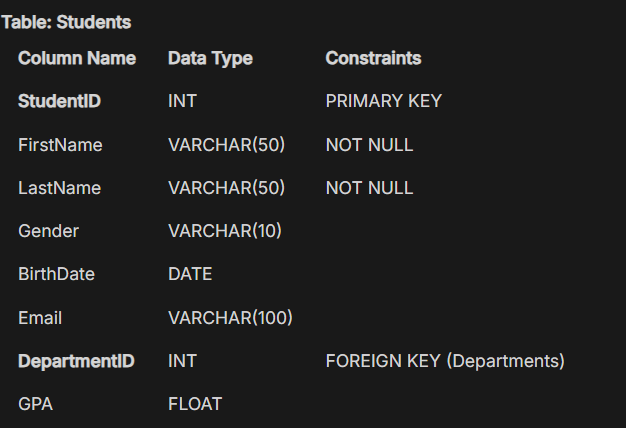

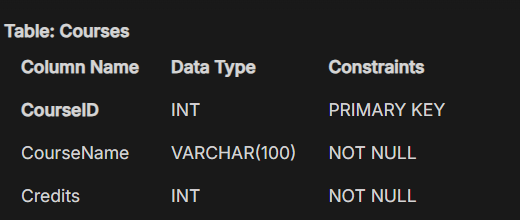

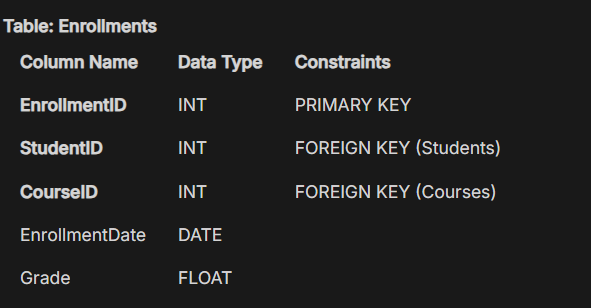

In [ ]:
db = sqlite3.connect('x.db')

cursor = db.cursor()

cursor.execute("""
CREATE TABLE Departments
(
    DepartmentID INT PRIMARY KEY,
    DepartmentName VARCHAR(100) NOT NULL
)
""")

cursor.execute("""
CREATE TABLE Students
(
    StudentID INT PRIMARY KEY,
    FirstName VARCHAR(50) NOT NULL,
    LastName VARCHAR(50) NOT NULL,
    Gender VARCHAR(10),
    BirthDate DATE,
    Email VARCHAR(100),
    DepartmentID INT,
    GPA float,

    FOREIGN KEY (DepartmentID)
        REFERENCES Departments(DepartmentID)
)
""")

cursor.execute("""
CREATE TABLE Courses
(
    CourseID INT PRIMARY KEY,
    CourseName VARCHAR(100) NOT NULL,
    Credits INT NOT NULL
)
""")

cursor.execute("""
CREATE TABLE Enrollments
(
    EnrollmentID INT PRIMARY KEY,
    StudentID INT NOT NULL,
    CourseID INT NOT NULL,
    EnrollmentDate DATE,
    Grade float,

    FOREIGN KEY (StudentID)
        REFERENCES Students(StudentID),

    FOREIGN KEY (CourseID)
        REFERENCES Courses(CourseID)
)
""")



db.commit() # nafz el sql code
db.close()

##How to insert data to table ?

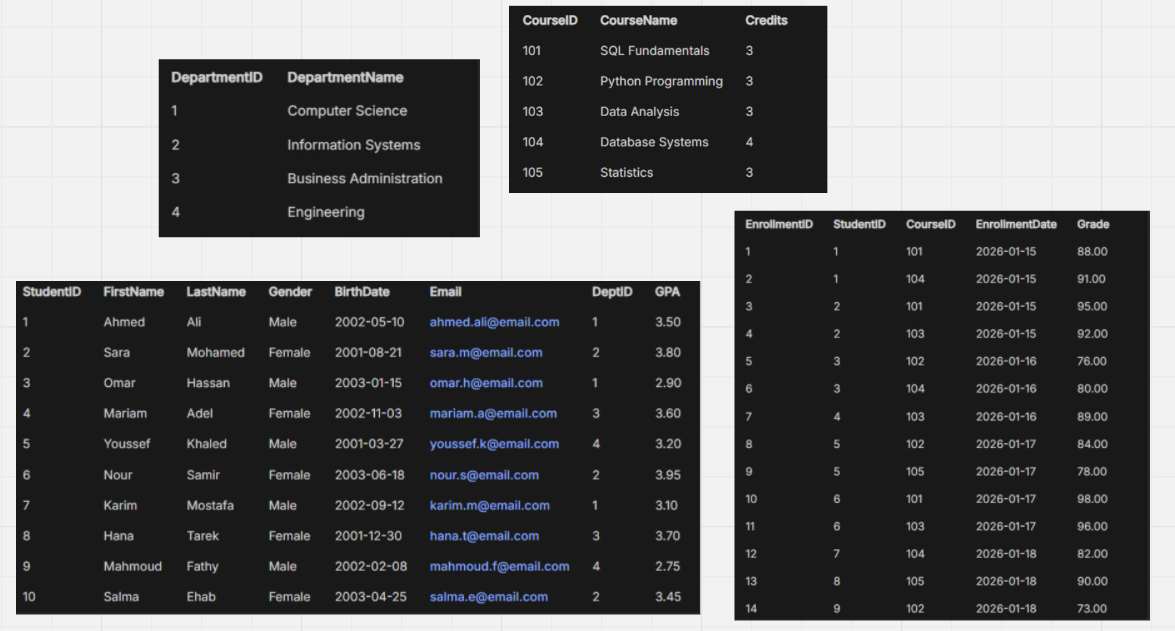

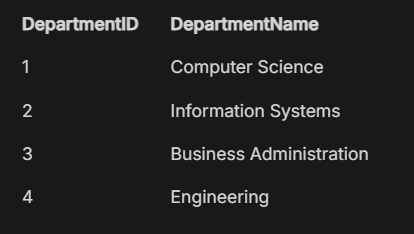

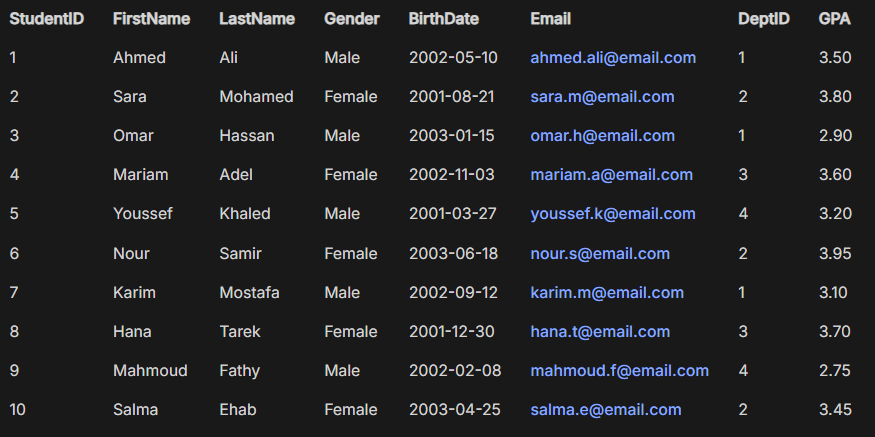

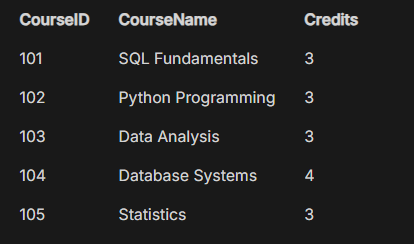

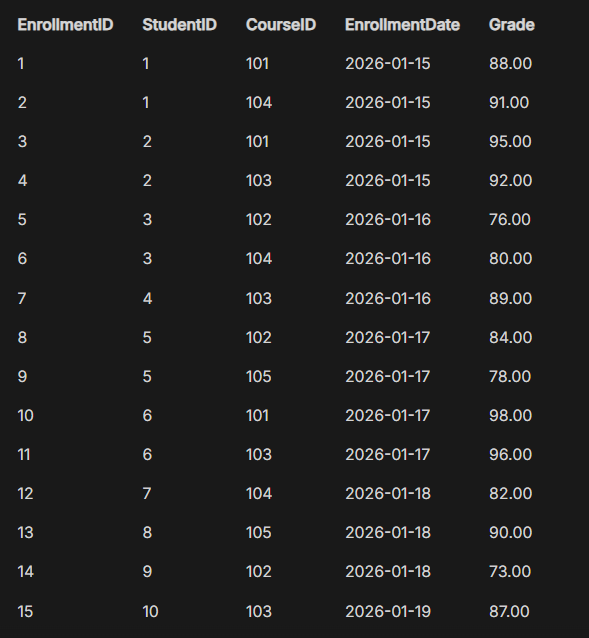

In [ ]:
db = sqlite3.connect('x.db')

cursor = db.cursor()

cursor.execute("""
INSERT INTO Departments
(
    DepartmentID,
    DepartmentName
)
VALUES
(1, 'Computer Science'),
(2, 'Information Systems'),
(3, 'Business Administration'),
(4, 'Engineering')
""")
cursor.execute("""
INSERT INTO Students
VALUES
(1, 'Ahmed', 'Ali', 'Male', '2002-05-10',
 'ahmed.ali@email.com', 1, 3.50),

(2, 'Sara', 'Mohamed', 'Female', '2001-08-21',
 'sara.m@email.com', 2, 3.80),

(3, 'Omar', 'Hassan', 'Male', '2003-01-15',
 'omar.h@email.com', 1, 2.90),

(4, 'Mariam', 'Adel', 'Female', '2002-11-03',
 'mariam.a@email.com', 3, 3.60),

(5, 'Youssef', 'Khaled', 'Male', '2001-03-27',
 'youssef.k@email.com', 4, 3.20),

(6, 'Nour', 'Samir', 'Female', '2003-06-18',
 'nour.s@email.com', 2, 3.95),

(7, 'Karim', 'Mostafa', 'Male', '2002-09-12',
 'karim.m@email.com', 1, 3.10),

(8, 'Hana', 'Tarek', 'Female', '2001-12-30',
 'hana.t@email.com', 3, 3.70),

(9, 'Mahmoud', 'Fathy', 'Male', '2002-02-08',
 'mahmoud.f@email.com', 4, 2.75),

(10, 'Salma', 'Ehab', 'Female', '2003-04-25',
 'salma.e@email.com', 2, 3.45)
""")
cursor.execute("""
INSERT INTO Courses
VALUES
(101, 'SQL Fundamentals', 3),
(102, 'Python Programming', 3),
(103, 'Data Analysis', 3),
(104, 'Database Systems', 4),
(105, 'Statistics', 3)
""")
cursor.execute("""
INSERT INTO Enrollments
VALUES
(1, 1, 101, '2026-01-15', 88.00),
(2, 1, 104, '2026-01-15', 91.00),

(3, 2, 101, '2026-01-15', 95.00),
(4, 2, 103, '2026-01-15', 92.00),

(5, 3, 102, '2026-01-16', 76.00),
(6, 3, 104, '2026-01-16', 80.00),

(7, 4, 103, '2026-01-16', 89.00),

(8, 5, 102, '2026-01-17', 84.00),
(9, 5, 105, '2026-01-17', 78.00),

(10, 6, 101, '2026-01-17', 98.00),
(11, 6, 103, '2026-01-17', 96.00),

(12, 7, 104, '2026-01-18', 82.00),

(13, 8, 105, '2026-01-18', 90.00),

(14, 9, 102, '2026-01-18', 73.00),

(15, 10, 103, '2026-01-19', 87.00)
""")
db.commit() # nafz el sql code
db.close()

##How To read the data ?

In [ ]:
db = sqlite3.connect('x.db')

cursor = db.cursor()

# rowid
data = cursor.execute("""
select  StudentID , FirstName
from Students
""")

for row in  data :
  print(row)

db.commit() # nafz el sql code
db.close()

(1, 'Ahmed')
(2, 'Sara')
(3, 'Omar')
(4, 'Mariam')
(5, 'Youssef')
(6, 'Nour')
(7, 'Karim')
(8, 'Hana')
(9, 'Mahmoud')
(10, 'Salma')


##Read Using Fetch

In [ ]:
db = sqlite3.connect('x.db')

cursor = db.cursor()

# rowid


data = cursor.execute("""
select  *
from Students
""")
# print(cursor.fetchone())
# print(cursor.fetchmany(3))
# print(cursor.fetchall())

df=cursor.fetchall()

db.commit() # nafz el sql code
db.close()

In [ ]:
df

[(1, 'Ahmed', 'Ali', 'Male', '2002-05-10', 'ahmed.ali@email.com', 1, 3.5),
 (2, 'Sara', 'Mohamed', 'Female', '2001-08-21', 'sara.m@email.com', 2, 3.8),
 (3, 'Omar', 'Hassan', 'Male', '2003-01-15', 'omar.h@email.com', 1, 2.9),
 (4, 'Mariam', 'Adel', 'Female', '2002-11-03', 'mariam.a@email.com', 3, 3.6),
 (5, 'Youssef', 'Khaled', 'Male', '2001-03-27', 'youssef.k@email.com', 4, 3.2),
 (6, 'Nour', 'Samir', 'Female', '2003-06-18', 'nour.s@email.com', 2, 3.95),
 (7, 'Karim', 'Mostafa', 'Male', '2002-09-12', 'karim.m@email.com', 1, 3.1),
 (8, 'Hana', 'Tarek', 'Female', '2001-12-30', 'hana.t@email.com', 3, 3.7),
 (9, 'Mahmoud', 'Fathy', 'Male', '2002-02-08', 'mahmoud.f@email.com', 4, 2.75),
 (10, 'Salma', 'Ehab', 'Female', '2003-04-25', 'salma.e@email.com', 2, 3.45)]

#Practical Questions

###1-Return All Students

In [ ]:
db = sqlite3.connect('x.db')

cursor = db.cursor()

# rowid


data = cursor.execute("""
select  *
from Students
""")

df=cursor.fetchall()



db.commit() # nafz el sql code



df

[(1, 'Ahmed', 'Ali', 'Male', '2002-05-10', 'ahmed.ali@email.com', 1, 3.5),
 (2, 'Sara', 'Mohamed', 'Female', '2001-08-21', 'sara.m@email.com', 2, 3.8),
 (3, 'Omar', 'Hassan', 'Male', '2003-01-15', 'omar.h@email.com', 1, 2.9),
 (4, 'Mariam', 'Adel', 'Female', '2002-11-03', 'mariam.a@email.com', 3, 3.6),
 (5, 'Youssef', 'Khaled', 'Male', '2001-03-27', 'youssef.k@email.com', 4, 3.2),
 (6, 'Nour', 'Samir', 'Female', '2003-06-18', 'nour.s@email.com', 2, 3.95),
 (7, 'Karim', 'Mostafa', 'Male', '2002-09-12', 'karim.m@email.com', 1, 3.1),
 (8, 'Hana', 'Tarek', 'Female', '2001-12-30', 'hana.t@email.com', 3, 3.7),
 (9, 'Mahmoud', 'Fathy', 'Male', '2002-02-08', 'mahmoud.f@email.com', 4, 2.75),
 (10, 'Salma', 'Ehab', 'Female', '2003-04-25', 'salma.e@email.com', 2, 3.45)]

###2. students whose GPA is greater than 3.5

In [ ]:


query = """
SELECT
    StudentID,
    FirstName,
    LastName,
    GPA
FROM Students
WHERE GPA > 3.5
"""

df = pd.read_sql_query(query, db)

df

,StudentID,FirstName,LastName,GPA
0,2,Sara,Mohamed,3.80
1,4,Mariam,Adel,3.60
2,6,Nour,Samir,3.95
3,8,Hana,Tarek,3.70


###3.How many students are in each department

In [ ]:
query = """
SELECT
    d.DepartmentName,
    COUNT(s.StudentID) AS StudentCount
FROM Departments d
LEFT JOIN Students s
    ON d.DepartmentID = s.DepartmentID
GROUP BY d.DepartmentName
ORDER BY StudentCount DESC
"""

df = pd.read_sql_query(query, db)

df

,DepartmentName,StudentCount
0,Information Systems,3
1,Computer Science,3
2,Engineering,2
3,Business Administration,2


###4.What is the average GPA for each department

In [ ]:
query = """
SELECT
    d.DepartmentName,
    ROUND(AVG(s.GPA), 2) AS AverageGPA
FROM Departments d
JOIN Students s
    ON d.DepartmentID = s.DepartmentID
GROUP BY d.DepartmentName
ORDER BY AverageGPA DESC
"""

df = pd.read_sql_query(query, db)

df

,DepartmentName,AverageGPA
0,Information Systems,3.73
1,Business Administration,3.65
2,Computer Science,3.17
3,Engineering,2.98


###5.What is the gender distribution of students

In [ ]:
query = """
SELECT
    Gender,
    COUNT(*) AS StudentCount
FROM Students
GROUP BY Gender
"""

df = pd.read_sql_query(query, db)

df

,Gender,StudentCount
0,Female,5
1,Male,5


###6.Which students have the highest grades

In [ ]:
query = """
SELECT
    s.FirstName,
    s.LastName,
    c.CourseName,
    e.Grade
FROM Students s JOIN Enrollments e
ON s.StudentID = e.StudentID
JOIN Courses c
ON e.CourseID = c.CourseID
ORDER BY e.Grade DESC
"""

df = pd.read_sql_query(query, db)

df

,FirstName,LastName,CourseName,Grade
0,Nour,Samir,SQL Fundamentals,98.0
1,Nour,Samir,Data Analysis,96.0
2,Sara,Mohamed,SQL Fundamentals,95.0
3,Sara,Mohamed,Data Analysis,92.0
4,Ahmed,Ali,Database Systems,91.0
5,Hana,Tarek,Statistics,90.0
6,Mariam,Adel,Data Analysis,89.0
7,Ahmed,Ali,SQL Fundamentals,88.0
8,Salma,Ehab,Data Analysis,87.0
9,Youssef,Khaled,Python Programming,84.0


###7.What is the average grade for each course

In [ ]:
query = """
SELECT
    c.CourseName,
    ROUND(AVG(e.Grade), 2) AS AverageGrade
FROM Courses c
JOIN Enrollments e
    ON c.CourseID = e.CourseID
GROUP BY c.CourseName
ORDER BY AverageGrade DESC
"""

df = pd.read_sql_query(query, db)

df

,CourseName,AverageGrade
0,SQL Fundamentals,93.67
1,Data Analysis,91.00
2,Database Systems,84.33
3,Statistics,84.00
4,Python Programming,77.67


###8.Which courses have an average grade below 85

In [ ]:
query = """
SELECT
    c.CourseName,
    ROUND(AVG(e.Grade), 2) AS AverageGrade
FROM Courses c
JOIN Enrollments e
    ON c.CourseID = e.CourseID
GROUP BY c.CourseName
HAVING AVG(e.Grade) < 85
"""

df = pd.read_sql_query(query, db)

df

,CourseName,AverageGrade
0,Database Systems,84.33
1,Python Programming,77.67
2,Statistics,84.00


###9.Which students are enrolled in more than one course

In [ ]:
query = """
SELECT
    s.StudentID,
    s.FirstName,
    s.LastName,
    COUNT(e.CourseID) AS NumberOfCourses
FROM Students s JOIN Enrollments e
ON s.StudentID = e.StudentID
GROUP BY
    s.StudentID,
    s.FirstName,
    s.LastName
"""

df = pd.read_sql_query(query, db)

df

,StudentID,FirstName,LastName,NumberOfCourses
0,1,Ahmed,Ali,2
1,2,Sara,Mohamed,2
2,3,Omar,Hassan,2
3,4,Mariam,Adel,1
4,5,Youssef,Khaled,2
5,6,Nour,Samir,2
6,7,Karim,Mostafa,1
7,8,Hana,Tarek,1
8,9,Mahmoud,Fathy,1
9,10,Salma,Ehab,1


###10Which department has the highest average GPA

In [ ]:
query = """
SELECT
    d.DepartmentName,
   ROUND(AVG(s.GPA), 2) AS AverageGPA
FROM Departments d
JOIN Students s
    ON d.DepartmentID = s.DepartmentID
GROUP BY d.DepartmentName
ORDER BY AverageGPA DESC
LIMIT 1
"""

df = pd.read_sql_query(query, db)

df

,DepartmentName,AverageGPA
0,Information Systems,3.73


###11.Which department has the largest number of students


In [ ]:
query = """
SELECT
    d.DepartmentName,
    COUNT(s.StudentID) AS StudentCount
FROM Departments d JOIN Students s
    ON d.DepartmentID = s.DepartmentID
GROUP BY d.DepartmentName
ORDER BY StudentCount DESC
LIMIT 1
"""
df = pd.read_sql_query(query, db)
df

,DepartmentName,StudentCount
0,Information Systems,3


### 12.Find students whose GPA is above the overall average GPA.

In [ ]:
query = """
SELECT
    StudentID,
    FirstName,
    LastName,
    GPA
FROM Students
WHERE GPA > (
    SELECT AVG(GPA)
    FROM Students
)
ORDER BY GPA DESC
"""

df = pd.read_sql_query(query, db)

df

,StudentID,FirstName,LastName,GPA
0,6,Nour,Samir,3.95
1,2,Sara,Mohamed,3.80
2,8,Hana,Tarek,3.70
3,4,Mariam,Adel,3.60
4,1,Ahmed,Ali,3.50
5,10,Salma,Ehab,3.45


###Case

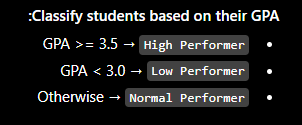

In [ ]:
query = """
SELECT
    FirstName,
    LastName,
    GPA,
    CASE
        WHEN GPA >= 3.5 THEN 'High Performer'
        WHEN GPA < 3.0 THEN 'Low Performer'
        ELSE 'Normal Performer'
    END AS PerformanceCategory
FROM Students
"""

df = pd.read_sql_query(query, db)

df

,FirstName,LastName,GPA,PerformanceCategory
0,Ahmed,Ali,3.50,High Performer
1,Sara,Mohamed,3.80,High Performer
2,Omar,Hassan,2.90,Low Performer
3,Mariam,Adel,3.60,High Performer
4,Youssef,Khaled,3.20,Normal Performer
5,Nour,Samir,3.95,High Performer
6,Karim,Mostafa,3.10,Normal Performer
7,Hana,Tarek,3.70,High Performer
8,Mahmoud,Fathy,2.75,Low Performer
9,Salma,Ehab,3.45,Normal Performer


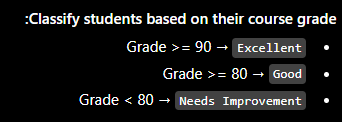

In [ ]:
query = """
SELECT
    s.FirstName,
    s.LastName,
    c.CourseName,
    e.Grade,
    CASE
        WHEN e.Grade >= 90 THEN 'Excellent'
        WHEN e.Grade >= 80 THEN 'Good'
        ELSE 'Needs Improvement'
    END AS PerformanceCategory
FROM Students s
JOIN Enrollments e
    ON s.StudentID = e.StudentID
JOIN Courses c
    ON e.CourseID = c.CourseID
"""

df = pd.read_sql_query(query, db)

df

,FirstName,LastName,CourseName,Grade,PerformanceCategory
0,Ahmed,Ali,SQL Fundamentals,88.0,Good
1,Ahmed,Ali,Database Systems,91.0,Excellent
2,Sara,Mohamed,SQL Fundamentals,95.0,Excellent
3,Sara,Mohamed,Data Analysis,92.0,Excellent
4,Omar,Hassan,Python Programming,76.0,Needs Improvement
5,Omar,Hassan,Database Systems,80.0,Good
6,Mariam,Adel,Data Analysis,89.0,Good
7,Youssef,Khaled,Python Programming,84.0,Good
8,Youssef,Khaled,Statistics,78.0,Needs Improvement
9,Nour,Samir,SQL Fundamentals,98.0,Excellent


### Using Window Function

1. Calculate the total number of students in each department.

In [ ]:
query = """
SELECT
    d.DepartmentName,
    COUNT(s.StudentID) AS StudentCount
FROM Departments d
JOIN Students s
    ON d.DepartmentID = s.DepartmentID
GROUP BY d.DepartmentName
"""

df = pd.read_sql_query(query, db)

df

,DepartmentName,StudentCount
0,Business Administration,2
1,Computer Science,3
2,Engineering,2
3,Information Systems,3


####2. Show each student and the average GPA of their department.

In [ ]:
query = """
SELECT
    s.FirstName,
    s.LastName,
    d.DepartmentName,
    s.GPA,
    ROUND(AVG(s.GPA) OVER (PARTITION BY s.DepartmentID), 2) AS DepartmentAvgGPA
FROM Students s
JOIN Departments d
    ON s.DepartmentID = d.DepartmentID
"""

df = pd.read_sql_query(query, db)

df

,FirstName,LastName,DepartmentName,GPA,DepartmentAvgGPA
0,Ahmed,Ali,Computer Science,3.50,3.17
1,Omar,Hassan,Computer Science,2.90,3.17
2,Karim,Mostafa,Computer Science,3.10,3.17
3,Sara,Mohamed,Information Systems,3.80,3.73
4,Nour,Samir,Information Systems,3.95,3.73
5,Salma,Ehab,Information Systems,3.45,3.73
6,Mariam,Adel,Business Administration,3.60,3.65
7,Hana,Tarek,Business Administration,3.70,3.65
8,Youssef,Khaled,Engineering,3.20,2.98
9,Mahmoud,Fathy,Engineering,2.75,2.98


####3. Show each student together with the highest and lowest GPA in their department.

In [ ]:
query = """
SELECT
    s.FirstName,
    s.LastName,
    d.DepartmentName,
    s.GPA,

    MIN(s.GPA) OVER (
        PARTITION BY s.DepartmentID
    ) AS MinDepartmentGPA,

    MAX(s.GPA) OVER (
        PARTITION BY s.DepartmentID
    ) AS MaxDepartmentGPA

FROM Students s
JOIN Departments d
    ON s.DepartmentID = d.DepartmentID
"""

df = pd.read_sql_query(query, db)

df

,FirstName,LastName,DepartmentName,GPA,MinDepartmentGPA,MaxDepartmentGPA
0,Ahmed,Ali,Computer Science,3.50,2.90,3.50
1,Omar,Hassan,Computer Science,2.90,2.90,3.50
2,Karim,Mostafa,Computer Science,3.10,2.90,3.50
3,Sara,Mohamed,Information Systems,3.80,3.45,3.95
4,Nour,Samir,Information Systems,3.95,3.45,3.95
5,Salma,Ehab,Information Systems,3.45,3.45,3.95
6,Mariam,Adel,Business Administration,3.60,3.60,3.70
7,Hana,Tarek,Business Administration,3.70,3.60,3.70
8,Youssef,Khaled,Engineering,3.20,2.75,3.20
9,Mahmoud,Fathy,Engineering,2.75,2.75,3.20


####4. Rank all students from highest GPA to lowest GPA using a unique row number.

In [ ]:
query = """
SELECT
    FirstName,
    LastName,
    GPA,
    ROW_NUMBER() OVER (
        ORDER BY GPA DESC
    ) AS RowNum
FROM Students
"""

df = pd.read_sql_query(query, db)

df

,FirstName,LastName,GPA,RowNum
0,Nour,Samir,3.95,1
1,Sara,Mohamed,3.80,2
2,Hana,Tarek,3.70,3
3,Mariam,Adel,3.60,4
4,Ahmed,Ali,3.50,5
5,Salma,Ehab,3.45,6
6,Youssef,Khaled,3.20,7
7,Karim,Mostafa,3.10,8
8,Omar,Hassan,2.90,9
9,Mahmoud,Fathy,2.75,10


####5. Rank students according to GPA. Students with the same GPA should receive the same rank.

In [ ]:
query = """
SELECT
    FirstName,
    LastName,
    GPA,
    RANK() OVER (
        ORDER BY GPA DESC
    ) AS GPArank
FROM Students
"""

df = pd.read_sql_query(query, db)

df

,FirstName,LastName,GPA,GPArank
0,Nour,Samir,3.95,1
1,Sara,Mohamed,3.80,2
2,Hana,Tarek,3.70,3
3,Mariam,Adel,3.60,4
4,Ahmed,Ali,3.50,5
5,Salma,Ehab,3.45,6
6,Youssef,Khaled,3.20,7
7,Karim,Mostafa,3.10,8
8,Omar,Hassan,2.90,9
9,Mahmoud,Fathy,2.75,10


####6. Create a dense ranking of students based on GPA.

In [ ]:
query = """
SELECT
    FirstName,
    LastName,
    GPA,
    DENSE_RANK() OVER (
        ORDER BY GPA DESC
    ) AS GPArank
FROM Students
"""

df = pd.read_sql_query(query, db)

df

,FirstName,LastName,GPA,GPArank
0,Nour,Samir,3.95,1
1,Sara,Mohamed,3.80,2
2,Hana,Tarek,3.70,3
3,Mariam,Adel,3.60,4
4,Ahmed,Ali,3.50,5
5,Salma,Ehab,3.45,6
6,Youssef,Khaled,3.20,7
7,Karim,Mostafa,3.10,8
8,Omar,Hassan,2.90,9
9,Mahmoud,Fathy,2.75,10


####7. Who is the top student in each department

In [ ]:
query = """
SELECT *
FROM
(
    SELECT
        FirstName,
        LastName,
        DepartmentID,
        GPA,
        ROW_NUMBER() OVER (
            PARTITION BY DepartmentID
            ORDER BY GPA DESC
        ) AS RankInDepartment
    FROM Students
)
WHERE RankInDepartment = 1
"""

df = pd.read_sql_query(query, db)

df

,FirstName,LastName,DepartmentID,GPA,RankInDepartment
0,Ahmed,Ali,1,3.50,1
1,Nour,Samir,2,3.95,1
2,Hana,Tarek,3,3.70,1
3,Youssef,Khaled,4,3.20,1


####8. Divide students into 2 groups based on GPA: high-performing group and lower-performing group.

In [ ]:
query = """
SELECT
    FirstName,
    LastName,
    GPA,
    NTILE(2) OVER (
        ORDER BY GPA DESC
    ) AS PerformanceGroup
FROM Students
"""

df = pd.read_sql_query(query, db)

df

,FirstName,LastName,GPA,PerformanceGroup
0,Nour,Samir,3.95,1
1,Sara,Mohamed,3.80,1
2,Hana,Tarek,3.70,1
3,Mariam,Adel,3.60,1
4,Ahmed,Ali,3.50,1
5,Salma,Ehab,3.45,2
6,Youssef,Khaled,3.20,2
7,Karim,Mostafa,3.10,2
8,Omar,Hassan,2.90,2
9,Mahmoud,Fathy,2.75,2


###Using CTE

1. Identify students whose GPA is greater than 3.5 using a CTE.

In [ ]:
query = """
WITH HighGPAStudents AS
(
    SELECT *
    FROM Students
    WHERE GPA > 3.5
)

SELECT *
FROM HighGPAStudents
"""

df = pd.read_sql_query(query, db)

df

,StudentID,FirstName,LastName,Gender,BirthDate,Email,DepartmentID,GPA
0,2,Sara,Mohamed,Female,2001-08-21,sara.m@email.com,2,3.80
1,4,Mariam,Adel,Female,2002-11-03,mariam.a@email.com,3,3.60
2,6,Nour,Samir,Female,2003-06-18,nour.s@email.com,2,3.95
3,8,Hana,Tarek,Female,2001-12-30,hana.t@email.com,3,3.70



####CTE + GROUP BY


2. Calculate the average GPA for each department using a CTE.

In [ ]:
query = """
WITH DepartmentGPA AS
(
    SELECT
        DepartmentID,
        AVG(GPA) AS AvgGPA
    FROM Students
    GROUP BY DepartmentID
)

SELECT *
FROM DepartmentGPA
"""

df = pd.read_sql_query(query, db)

df

,DepartmentID,AvgGPA
0,1,3.166667
1,2,3.733333
2,3,3.650000
3,4,2.975000


####CTE + HAVING

3. Find departments where the average GPA is greater than 3.5.

In [ ]:
query = """
WITH DepartmentGPA AS
(
    SELECT
        DepartmentID,
        AVG(GPA) AS AvgGPA
    FROM Students
    GROUP BY DepartmentID
)

SELECT *
FROM DepartmentGPA
WHERE AvgGPA > 3.5
"""

df = pd.read_sql_query(query, db)

df

,DepartmentID,AvgGPA
0,2,3.733333
1,3,3.650000


####CTE + JOIN

4. Find the student who has the highest GPA in each department.

In [ ]:
query = """
WITH DepartmentMaxGPA AS
(
    SELECT
        DepartmentID,
        MAX(GPA) AS MaxGPA
    FROM Students
    GROUP BY DepartmentID
)

SELECT
    s.FirstName,
    s.LastName,
    s.DepartmentID,
    s.GPA
FROM Students s
JOIN DepartmentMaxGPA d
    ON s.DepartmentID = d.DepartmentID
    AND s.GPA = d.MaxGPA
"""

df = pd.read_sql_query(query, db)

df

,FirstName,LastName,DepartmentID,GPA
0,Ahmed,Ali,1,3.50
1,Youssef,Khaled,4,3.20
2,Nour,Samir,2,3.95
3,Hana,Tarek,3,3.70


####Multiple CTE

6. Find students who belong to departments whose average GPA is greater than 3.5

In [ ]:
query = """
WITH DepartmentAvg AS
(
    SELECT
        DepartmentID,
        AVG(GPA) AS AvgGPA
    FROM Students
    GROUP BY DepartmentID
),

HighPerformingDepartments AS
(
    SELECT
        DepartmentID,
        AvgGPA
    FROM DepartmentAvg
    WHERE AvgGPA > 3.5
)

SELECT
    s.FirstName,
    s.LastName,
    s.DepartmentID,
    s.GPA
FROM Students s
JOIN HighPerformingDepartments h
    ON s.DepartmentID = h.DepartmentID;
"""

df = pd.read_sql_query(query, db)

df

,FirstName,LastName,DepartmentID,GPA
0,Sara,Mohamed,2,3.80
1,Mariam,Adel,3,3.60
2,Nour,Samir,2,3.95
3,Hana,Tarek,3,3.70
4,Salma,Ehab,2,3.45


####CTE + Window Function

7. Rank students according to GPA using a CTE.

In [ ]:
query = """
WITH StudentRanking AS
(
    SELECT
        FirstName,
        LastName,
        DepartmentID,
        GPA,
        RANK() OVER (
            ORDER BY GPA DESC
        ) AS GPArank
    FROM Students
)

SELECT *
FROM StudentRanking;
"""

df = pd.read_sql_query(query, db)

df

,FirstName,LastName,DepartmentID,GPA,GPArank
0,Nour,Samir,2,3.95,1
1,Sara,Mohamed,2,3.80,2
2,Hana,Tarek,3,3.70,3
3,Mariam,Adel,3,3.60,4
4,Ahmed,Ali,1,3.50,5
5,Salma,Ehab,2,3.45,6
6,Youssef,Khaled,4,3.20,7
7,Karim,Mostafa,1,3.10,8
8,Omar,Hassan,1,2.90,9
9,Mahmoud,Fathy,4,2.75,10


##Temporary Table

1. Create a temporary table containing high-performing students with GPA > 3.5.

In [ ]:
cursor = db.cursor()

cursor.execute("""
CREATE TEMP TABLE HighGPA AS
SELECT *
FROM Students
WHERE GPA > 3.5
""")

db.commit()

df = pd.read_sql_query(
    "SELECT * FROM HighGPA",
    db
)

df

,StudentID,FirstName,LastName,Gender,BirthDate,Email,DepartmentID,GPA
0,2,Sara,Mohamed,Female,2001-08-21,sara.m@email.com,2,3.80
1,4,Mariam,Adel,Female,2002-11-03,mariam.a@email.com,3,3.60
2,6,Nour,Samir,Female,2003-06-18,nour.s@email.com,2,3.95
3,8,Hana,Tarek,Female,2001-12-30,hana.t@email.com,3,3.70


2. Create a temporary copy of students and increase their GPA by 5%.


In [ ]:
cursor.execute("""
CREATE TEMP TABLE StudentTemp AS
SELECT *
FROM Students
""")

cursor.execute("""
UPDATE StudentTemp
SET GPA = GPA * 1.05
""")

db.commit()

df = pd.read_sql_query(
    "SELECT * FROM StudentTemp",
    db
)

df

,StudentID,FirstName,LastName,Gender,BirthDate,Email,DepartmentID,GPA
0,1,Ahmed,Ali,Male,2002-05-10,ahmed.ali@email.com,1,3.6750
1,2,Sara,Mohamed,Female,2001-08-21,sara.m@email.com,2,3.9900
2,3,Omar,Hassan,Male,2003-01-15,omar.h@email.com,1,3.0450
3,4,Mariam,Adel,Female,2002-11-03,mariam.a@email.com,3,3.7800
4,5,Youssef,Khaled,Male,2001-03-27,youssef.k@email.com,4,3.3600
5,6,Nour,Samir,Female,2003-06-18,nour.s@email.com,2,4.1475
6,7,Karim,Mostafa,Male,2002-09-12,karim.m@email.com,1,3.2550
7,8,Hana,Tarek,Female,2001-12-30,hana.t@email.com,3,3.8850
8,9,Mahmoud,Fathy,Male,2002-02-08,mahmoud.f@email.com,4,2.8875
9,10,Salma,Ehab,Female,2003-04-25,salma.e@email.com,2,3.6225


###View

1. Create a view showing student name, department, and GPA.

In [ ]:
cursor.execute("""
CREATE VIEW StudentDepartmentInfo AS

SELECT
    s.FirstName,
    s.LastName,
    d.DepartmentName,
    s.GPA
FROM Students s
JOIN Departments d
    ON s.DepartmentID = d.DepartmentID
""")

db.commit()

df = pd.read_sql_query(
    "SELECT * FROM StudentDepartmentInfo",
    db
)

df

,FirstName,LastName,DepartmentName,GPA
0,Ahmed,Ali,Computer Science,3.50
1,Sara,Mohamed,Information Systems,3.80
2,Omar,Hassan,Computer Science,2.90
3,Mariam,Adel,Business Administration,3.60
4,Youssef,Khaled,Engineering,3.20
5,Nour,Samir,Information Systems,3.95
6,Karim,Mostafa,Computer Science,3.10
7,Hana,Tarek,Business Administration,3.70
8,Mahmoud,Fathy,Engineering,2.75
9,Salma,Ehab,Information Systems,3.45


2. Create a view showing high-performing students and their departments.

In [ ]:
cursor.execute("""
CREATE VIEW HighGPAStudentInfo AS

SELECT
    s.FirstName,
    s.LastName,
    d.DepartmentName,
    s.GPA
FROM Students s
JOIN Departments d
    ON s.DepartmentID = d.DepartmentID
WHERE s.GPA > 3.5;
""")

db.commit()

df = pd.read_sql_query(
    "SELECT * FROM StudentDepartmentInfo",
    db
)

df

,FirstName,LastName,DepartmentName,GPA
0,Ahmed,Ali,Computer Science,3.50
1,Sara,Mohamed,Information Systems,3.80
2,Omar,Hassan,Computer Science,2.90
3,Mariam,Adel,Business Administration,3.60
4,Youssef,Khaled,Engineering,3.20
5,Nour,Samir,Information Systems,3.95
6,Karim,Mostafa,Computer Science,3.10
7,Hana,Tarek,Business Administration,3.70
8,Mahmoud,Fathy,Engineering,2.75
9,Salma,Ehab,Information Systems,3.45


3. Create a view showing the number of students and average GPA for each department.

In [ ]:
cursor.execute("""
CREATE VIEW DepartmentStatistics AS

SELECT
    d.DepartmentName,
    COUNT(s.StudentID) AS StudentCount,
    ROUND(AVG(s.GPA), 2) AS AvgGPA
FROM Departments d
LEFT JOIN Students s
    ON d.DepartmentID = s.DepartmentID
GROUP BY d.DepartmentName
""")

db.commit()

df = pd.read_sql_query(
    "SELECT * FROM DepartmentStatistics",
    db
)

df

,DepartmentName,StudentCount,AvgGPA
0,Business Administration,2,3.65
1,Computer Science,3,3.17
2,Engineering,2,2.98
3,Information Systems,3,3.73


###VIEW + Window Function

4. Create a view that ranks students by GPA within each department.

In [ ]:
cursor.execute("""
CREATE VIEW StudentDepartmentRanking AS

SELECT
    s.StudentID,
    s.FirstName,
    s.LastName,
    d.DepartmentName,
    s.GPA,

    ROW_NUMBER() OVER (
        PARTITION BY s.DepartmentID
        ORDER BY s.GPA DESC
    ) AS RankInDepartment

FROM Students s
JOIN Departments d
    ON s.DepartmentID = d.DepartmentID
""")

db.commit()

df = pd.read_sql_query(
    "SELECT * FROM StudentDepartmentRanking",
    db
)

df

,StudentID,FirstName,LastName,DepartmentName,GPA,RankInDepartment
0,1,Ahmed,Ali,Computer Science,3.50,1
1,7,Karim,Mostafa,Computer Science,3.10,2
2,3,Omar,Hassan,Computer Science,2.90,3
3,6,Nour,Samir,Information Systems,3.95,1
4,2,Sara,Mohamed,Information Systems,3.80,2
5,10,Salma,Ehab,Information Systems,3.45,3
6,8,Hana,Tarek,Business Administration,3.70,1
7,4,Mariam,Adel,Business Administration,3.60,2
8,5,Youssef,Khaled,Engineering,3.20,1
9,9,Mahmoud,Fathy,Engineering,2.75,2


#Load your Own Data

1. create  connection between sql and python

2. convert excel sheets into table inside sqlite



In [ ]:
import pandas as pd
import sqlite3

# Read Excel
customers_table = pd.read_excel('/content/Customers.xlsx')
Products_table = pd.read_excel('/content/Product.xlsx')
return_table = pd.read_excel('/content/Returns.xlsx')
sales_table = pd.read_excel('/content/Sales.xlsx')

# Connect to SQLite
conn = sqlite3.connect('project.db')

# Send DataFrame to SQLite as a table
#Excel → Pandas DataFrame → SQLite Table
customers_table.to_sql('Customers', conn, if_exists='replace', index=False)
Products_table.to_sql('Products', conn, if_exists='replace', index=False)
return_table.to_sql('returns', conn, if_exists='replace', index=False)
sales_table.to_sql('sales', conn, if_exists='replace', index=False)

60855

In [ ]:
customers_table.columns

Index(['CustomerKey', 'GeographyKey', 'BusinessType', 'Customer',
       'NumberEmployees', 'AnnualRevenue', 'YearOpened', 'CityName',
       'StateCode', 'StateName', 'CountryCode', 'CountryName', 'RegionKey',
       'Region', 'Continent'],
      dtype='object')

Read the file

In [ ]:
query = """
SELECT *
FROM Customers
"""

result = pd.read_sql_query(query, conn)

result

,CustomerKey,GeographyKey,BusinessType,Customer,NumberEmployees,AnnualRevenue,YearOpened,CityName,StateCode,StateName,CountryCode,CountryName,RegionKey,Region,Continent
0,1,637,Supplement Store,Supplements Aid,2,30000,1974,Seattle,WA,Washington,US,United States,1,Northwest,North America
1,146,637,Supplement Store,Monster Well,14,80000,1995,Seattle,WA,Washington,US,United States,1,Northwest,North America
2,236,637,Warehouse,BodyBuild Department,55,300000,2003,Seattle,WA,Washington,US,United States,1,Northwest,North America
3,397,637,Supplement Store,Nutrition Macho,3,30000,1985,Seattle,WA,Washington,US,United States,1,Northwest,North America
4,2,635,Gym,Guardian Gym,10,80000,1976,Renton,WA,Washington,US,United States,1,Northwest,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
696,697,601,Supplement Store,Monster Progress,12,80000,1992,Tooele,UT,Utah,US,United States,1,Northwest,North America
697,698,595,Gym,Gravity Fitness,48,150000,1998,Cedar City,UT,Utah,US,United States,1,Northwest,North America
698,699,496,Warehouse,Shield Warehouse,80,300000,1991,Kannapolis,NC,North Carolina,US,United States,5,Southeast,North America
699,700,494,Supplement Store,Supplements Care,11,80000,1997,Charlotte,NC,North Carolina,US,United States,5,Southeast,North America


In [ ]:
query = """
SELECT *
FROM products
"""

result = pd.read_sql_query(query, conn)

result

,ProductKey,ProductSubcategoryKey,ProductName,Size,Detail,SubcategoryName,CategoryName
0,211,16,100% Vegan Protein,5lbs,Coconut,Vegan Protein,Protein
1,212,18,Opti-Women Multivitamin,60 Capsules,None,Vitamins,Vitamins
2,213,18,Men Multivitamin for Men,240 Tablets,None,Vitamins,Vitamins
3,214,18,VITASTACK,30 Multi-Packs,None,Vitamins,Vitamins
4,215,18,Women Multivitamin,120 Capsules,None,Vitamins,Vitamins
...,...,...,...,...,...,...,...
344,601,1,Xtend Original BCAA,30 Servings,None,BCAA,Amino Acids
345,603,4,ONE,36 oz,Natural,Meal Replacement,Carbs
346,604,17,Isolate Whey Protein,1lbs,Coconut,Whey Protein,Protein
347,605,14,Pure Casein Protein,1lbs,Caramel Ice Cream,Casein Protein,Protein


In [ ]:
query = """
SELECT *
FROM sales
"""

result = pd.read_sql_query(query, conn)

result

,SalesDetailsKey,SalesHeaderKey,SalesOrderNumber,ProductKey,ProductSubcategoryKey,OrderQuantity,UnitPrice,ExtendedAmount,OrderDate,DueDate,ShipDate,CustomerKey,RegionKey,DiscountAmount,TotalAmount,SalesAmount
0,1,2194,SO43659,220,18,4,20.1865,80.7460,2010-12-29 00:00:00,2011-01-10 00:00:00,2011-05-01 00:00:00,676,5,543.00,20565.62,20022.62
1,2,2194,SO43659,223,10,2,5.1865,10.3730,2010-12-29 00:00:00,2011-01-10 00:00:00,2011-05-01 00:00:00,676,5,543.00,20565.62,20022.62
2,3,2194,SO43659,346,17,2,2039.9940,4079.9880,2010-12-29 00:00:00,2011-01-10 00:00:00,2011-05-01 00:00:00,676,5,543.00,20565.62,20022.62
3,4,2194,SO43659,349,17,1,2024.9940,2024.9940,2010-12-29 00:00:00,2011-01-10 00:00:00,2011-05-01 00:00:00,676,5,543.00,20565.62,20022.62
4,5,2194,SO43659,350,17,3,2024.9940,6074.9820,2010-12-29 00:00:00,2011-01-10 00:00:00,2011-05-01 00:00:00,676,5,543.00,20565.62,20022.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60850,60851,128,SO71952,359,17,8,1376.9940,11015.9520,2013-11-29 00:00:00,2013-12-11 00:00:00,2013-06-12 00:00:00,490,4,1269.32,67404.90,66135.58
60851,60852,128,SO71952,516,1,9,23.4840,211.3560,2013-11-29 00:00:00,2013-12-11 00:00:00,2013-06-12 00:00:00,490,4,1269.32,67404.90,66135.58
60852,60853,128,SO71952,353,17,10,1391.9940,13919.9400,2013-11-29 00:00:00,2013-12-11 00:00:00,2013-06-12 00:00:00,490,4,1269.32,67404.90,66135.58
60853,60854,128,SO71952,552,1,10,54.8940,548.9400,2013-11-29 00:00:00,2013-12-11 00:00:00,2013-06-12 00:00:00,490,4,1269.32,67404.90,66135.58


In [ ]:
query = """
SELECT *
FROM returns
"""

result = pd.read_sql_query(query, conn)

result

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,ReturnKey,ReturnDate,OrderDate,SalesOrderNumber,CustomerKey,ProductKey,ReturnQuantity,UnitPrice,ReturnAmount
0,None,None,None,None,None,1,2011-01-10 00:00:00,2010-12-29 00:00:00,SO43665,146,348,2,2024.994,4049.988
1,None,None,None,None,None,2,2011-02-15 00:00:00,2011-01-29 00:00:00,SO43867,145,296,2,714.704,1429.409
2,None,None,None,None,None,3,2011-04-07 00:00:00,2011-03-31 00:00:00,SO44285,397,351,2,2024.994,4049.988
3,None,None,None,None,None,4,2011-05-21 00:00:00,2011-05-01 00:00:00,SO44540,469,212,2,20.187,40.373
4,None,None,None,None,None,5,2011-05-16 00:00:00,2011-05-01 00:00:00,SO44570,218,328,2,419.459,838.918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3864,None,None,None,None,None,3865,2013-10-17 00:00:00,2013-09-29 00:00:00,SO67266,146,353,11,1345.594,14801.536
3865,None,None,None,None,None,3866,2012-04-13 00:00:00,2012-03-30 00:00:00,SO47666,146,470,14,22.034,308.479
3866,None,None,None,None,None,3867,2012-10-17 00:00:00,2012-09-28 00:00:00,SO49826,146,470,19,20.895,396.996
3867,None,None,None,None,None,3868,2013-10-07 00:00:00,2013-09-29 00:00:00,SO67266,146,474,38,34.995,1329.810


get only the customer that make orders


In [ ]:
query = """
select Customer
from sales inner join Customers
on Customers.CustomerKey = sales.CustomerKey
"""

result = pd.read_sql_query(query, conn)

result

,Customer
0,Supplements Gun
1,Supplements Gun
2,Supplements Gun
3,Supplements Gun
4,Supplements Gun
...,...
60850,Bounce Warehouse
60851,Bounce Warehouse
60852,Bounce Warehouse
60853,Bounce Warehouse


get the customers that make returns


In [ ]:
query = """
select Customer
from returns inner join Customers
on Customers.CustomerKey = returns.CustomerKey
"""

result = pd.read_sql_query(query, conn)

result

,Customer
0,Monster Well
1,Heart Sports
2,Nutrition Macho
3,Strength Store
4,Supplements Jog
...,...
3864,Monster Well
3865,Monster Well
3866,Monster Well
3867,Monster Well


get the customers that not make Orders

In [ ]:
query = """
select Customer , sales.CustomerKey as "id_Sales", Customers.CustomerKey
from Customers left join sales
on Customers.CustomerKey = sales.CustomerKey
where sales.CustomerKey is null

"""

result = pd.read_sql_query(query, conn)

result

,Customer,id_Sales,CustomerKey
0,Enhance Store,None,105
1,Hammer Department,None,402
2,Nutrition Nurse,None,188
3,The Training Room,None,192
4,Titan Gym,None,537
...,...,...,...
61,Physical Department,None,508
62,Juggernaut Sports,None,657
63,Nutrition Athletic,None,658
64,Quads Gym,None,671


get the top (3) returned Product


In [ ]:
query = """
select *
from Products join returns
on Products.ProductKey = returns.ProductKey
order by ReturnQuantity desc
limit 3
"""
result = pd.read_sql_query(query, conn)

result

,ProductKey,ProductSubcategoryKey,ProductName,Size,Detail,SubcategoryName,CategoryName,Unnamed: 0,Unnamed: 1,Unnamed: 2,...,Unnamed: 4,ReturnKey,ReturnDate,OrderDate,SalesOrderNumber,CustomerKey,ProductKey,ReturnQuantity,UnitPrice,ReturnAmount
0,476,8,Women's Gym Shorts,L,Black,Shorts,Clothing,None,None,None,...,None,3869,2013-10-16 00:00:00,2013-09-29 00:00:00,SO67266,146,476,41,31.496,1291.316
1,474,8,Women's Gym Shorts,S,Black,Shorts,Clothing,None,None,None,...,None,3868,2013-10-07 00:00:00,2013-09-29 00:00:00,SO67266,146,474,38,34.995,1329.810
2,470,5,Full-Finger Gloves,L,Black,Gloves,Clothing,None,None,None,...,None,3038,2012-06-15 00:00:00,2012-05-30 00:00:00,SO48318,327,470,26,18.995,493.870


get the top (5) customers make return

In [ ]:
query = """
select  *
from Customers join returns
on Customers.CustomerKey = returns.CustomerKey
order by ReturnQuantity desc
limit 5
"""

result = pd.read_sql_query(query, conn)

result

,CustomerKey,GeographyKey,BusinessType,Customer,NumberEmployees,AnnualRevenue,YearOpened,CityName,StateCode,StateName,...,Unnamed: 4,ReturnKey,ReturnDate,OrderDate,SalesOrderNumber,CustomerKey,ProductKey,ReturnQuantity,UnitPrice,ReturnAmount
0,146,637,Supplement Store,Monster Well,14,80000,1995,Seattle,WA,Washington,...,None,3869,2013-10-16 00:00:00,2013-09-29 00:00:00,SO67266,146,476,41,31.496,1291.316
1,146,637,Supplement Store,Monster Well,14,80000,1995,Seattle,WA,Washington,...,None,3868,2013-10-07 00:00:00,2013-09-29 00:00:00,SO67266,146,474,38,34.995,1329.810
2,327,487,Supplement Store,Monster Quest,17,80000,2001,Saint Louis,MO,Missouri,...,None,3038,2012-06-15 00:00:00,2012-05-30 00:00:00,SO48318,327,470,26,18.995,493.870
3,494,409,Supplement Store,Monster Nutritious,7,30000,1991,Miami,FL,Florida,...,None,3054,2013-07-19 00:00:00,2013-06-30 00:00:00,SO61217,494,474,23,38.495,885.374
4,697,601,Supplement Store,Monster Progress,12,80000,1992,Tooele,UT,Utah,...,None,3040,2012-11-05 00:00:00,2012-10-28 00:00:00,SO50270,697,469,23,20.895,480.574


unique customer ?


In [ ]:
query = """
select distinct customerkey
from sales
"""

result = pd.read_sql_query(query, conn)

result

,CustomerKey
0,676
1,385
2,117
3,442
4,417
...,...
630,659
631,699
632,501
633,244


what is the total number of customer ?

In [ ]:
query = """
select count(distinct customerkey)
from sales
"""

result = pd.read_sql_query(query, conn)

result

,count(distinct customerkey)
0,635


what is the total number of customer ?

In [ ]:
query = """
select count(distinct customerkey)
from customers
"""

result = pd.read_sql_query(query, conn)

result

,count(distinct customerkey)
0,701


what is the total revenue ?

In [ ]:
query = """
select sum(totalamount) as REV
from sales
"""

result = pd.read_sql_query(query, conn)

result

,REV
0,2.568602e+09


what is the average of qty sold ?

In [ ]:
query = """
select AVG(orderquantity)
from sales
"""

result = pd.read_sql_query(query, conn)

result

,AVG(orderquantity)
0,3.522767


get the biggest product according to QTY

In [ ]:
query = """
select MAX(orderquantity)
from sales
"""

result = pd.read_sql_query(query, conn)

result

,MAX(orderquantity)
0,44


what is the revenue Per contintent

In [ ]:
query = """
select continent , sum(totalamount)
from customers join sales
on customers.customerkey = sales.customerkey
group by continent
"""

result = pd.read_sql_query(query, conn)

result

,Continent,sum(totalamount)
0,Europe,4.086590e+08
1,North America,2.098339e+09
2,South America,6.160369e+07


what is the total qty sold by each category

In [ ]:
query = """
select categoryname , sum(totalamount)
from Products join sales
on Products.productkey = sales.productkey
group by categoryname
"""

result = pd.read_sql_query(query, conn)

result

,CategoryName,sum(totalamount)
0,Amino Acids,2.477764e+08
1,Carbs,4.537923e+08
2,Clothing,4.794576e+08
3,Protein,1.174169e+09
4,Vitamins,2.134064e+08


get the total revenue in each year

In [ ]:
query = """
SELECT
    strftime('%Y', OrderDate) AS OrderYear,
    SUM(TotalAmount) AS TotalSales
FROM Sales
GROUP BY strftime('%Y', OrderDate)
"""

result = pd.read_sql_query(query, conn)

result

,OrderYear,TotalSales
0,2010,7.174123e+06
1,2011,3.794678e+08
2,2012,1.028726e+09
3,2013,1.153234e+09


#Stored Procedure

a saved set of SQL code stored directly inside a database

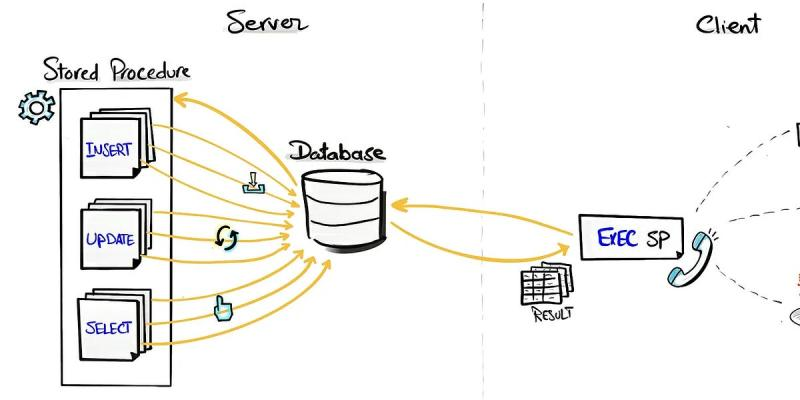

1. Who are the top 3 students with the highest GPA?

In [ ]:
def get_top_students():
    query = """
    SELECT
        StudentID,
        FirstName,
        LastName,
        GPA
    FROM Students
    ORDER BY GPA DESC
    LIMIT 3
    """

    return pd.read_sql_query(query, db)


result = get_top_students()
result

,StudentID,FirstName,LastName,GPA
0,6,Nour,Samir,3.95
1,2,Sara,Mohamed,3.80
2,8,Hana,Tarek,3.70


2. What is the average GPA for each department?

In [ ]:
def get_department_average_gpa():

    query = """
    SELECT
        d.DepartmentName,
        ROUND(AVG(s.GPA), 2) AS AverageGPA
    FROM Departments d
    JOIN Students s
        ON d.DepartmentID = s.DepartmentID
    GROUP BY
        d.DepartmentName
    ORDER BY
        AverageGPA DESC
    """

    return pd.read_sql_query(query, db)


result = get_department_average_gpa()
result

,DepartmentName,AverageGPA
0,Information Systems,3.73
1,Business Administration,3.65
2,Computer Science,3.17
3,Engineering,2.98


3.Which department has the highest average GPA?

In [ ]:
def get_best_department():

    query = """
    SELECT
        d.DepartmentName,
        ROUND(AVG(s.GPA), 2) AS AverageGPA
    FROM Departments d
    JOIN Students s
        ON d.DepartmentID = s.DepartmentID
    GROUP BY
        d.DepartmentName
    ORDER BY
        AverageGPA DESC
    LIMIT 1
    """

    return pd.read_sql_query(query, db)


result = get_best_department()
result

,DepartmentName,AverageGPA
0,Information Systems,3.73
